In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, losses
import matplotlib.pyplot as plt
import time
import pandas as pd
from skimage.metrics import structural_similarity as ssim

# Set seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load MNIST Dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Recommended laboratory subset: 10,000 training, 2,000 test images
x_train = x_train_full[:10000].astype('float32') / 255.0
y_train = y_train_full[:10000]
x_test = x_test_full[:2000].astype('float32') / 255.0
y_test = y_test_full[:2000]

# Reshape for Convolutional and FC models
x_train_conv = np.expand_dims(x_train, axis=-1)  # (10000, 28, 28, 1)
x_test_conv = np.expand_dims(x_test, axis=-1)    # (2000, 28, 28, 1)

x_train_flat = x_train.reshape((-1, 784))        # (10000, 784)
x_test_flat = x_test.reshape((-1, 784))          # (2000, 784)

print(f"Train shapes: Flat={x_train_flat.shape}, Conv={x_train_conv.shape}")
print(f"Test shapes:  Flat={x_test_flat.shape}, Conv={x_test_conv.shape}")

# Utility Function for Evaluation Metrics
def compute_metrics(original, reconstructed):
    """Computes MSE, MAE, and SSIM between original and reconstructed images."""
    orig = original.reshape(-1, 28, 28)
    recon = reconstructed.reshape(-1, 28, 28)

    mse = np.mean((orig - recon) ** 2)
    mae = np.mean(np.abs(orig - recon))

    ssim_list = [ssim(orig[i], recon[i], data_range=1.0) for i in range(len(orig))]
    mean_ssim = np.mean(ssim_list)

    return mse, mae, mean_ssim

# Master dataframe for consolidated results
consolidated_results = []
print("Dataset setup completed successfully.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shapes: Flat=(10000, 784), Conv=(10000, 28, 28, 1)
Test shapes:  Flat=(2000, 784), Conv=(2000, 28, 28, 1)
Dataset setup completed successfully.


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.3398 - val_loss: 0.2568
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2432 - val_loss: 0.2244
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2126 - val_loss: 0.1976
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1903 - val_loss: 0.1828
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1752 - val_loss: 0.1696
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1629 - val_loss: 0.1599
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1547 - val_loss: 0.1536
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1496 - val_loss: 0.1493
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1458 - val_loss: 0.1459
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1428 - val_loss: 0.1434
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1405 - val_loss: 0.1415
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1384 - val_l

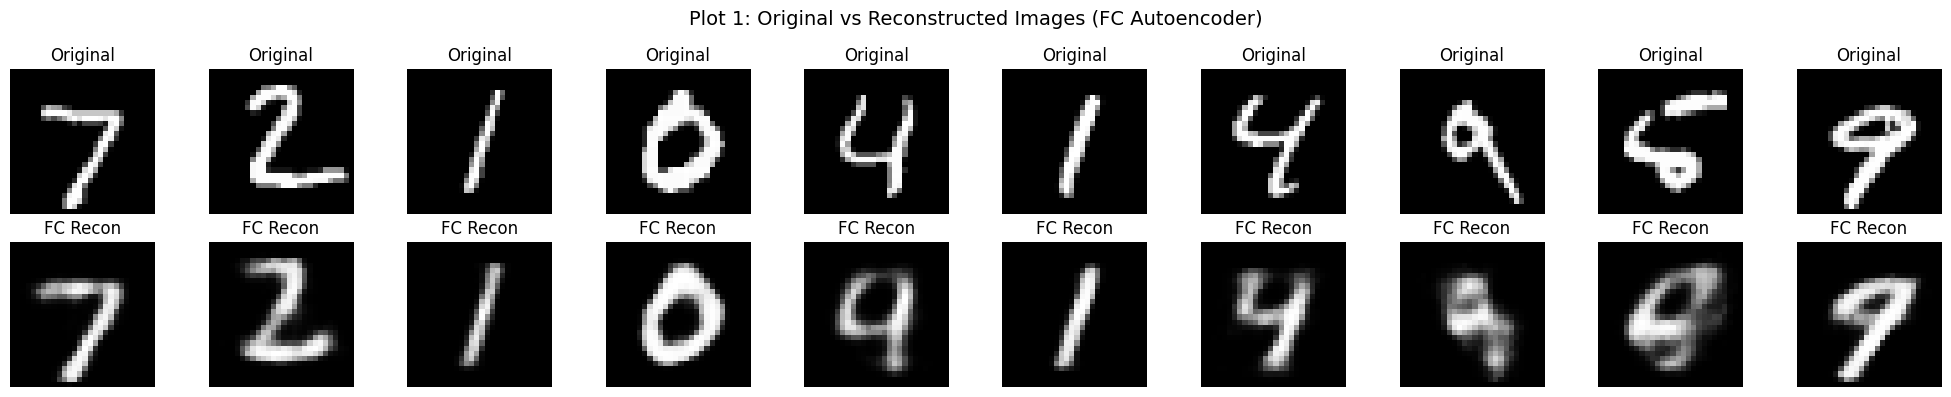

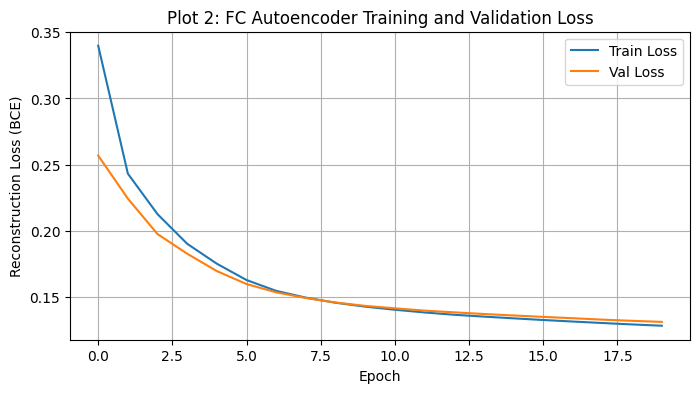

In [ ]:
# 1. Build Fully Connected Autoencoder Architecture using Functional API
inputs_fc = layers.Input(shape=(784,), name="input_layer")

# Encoder
x = layers.Dense(128, activation='relu')(inputs_fc)
x = layers.Dense(32, activation='relu')(x)
latent_fc = layers.Dense(16, activation='relu', name='latent_space')(x)
fc_encoder = models.Model(inputs_fc, latent_fc, name="FC_Encoder")

# Decoder
decoder_inputs = layers.Input(shape=(16,), name="decoder_input")
y = layers.Dense(32, activation='relu')(decoder_inputs)
y = layers.Dense(128, activation='relu')(y)
outputs_fc = layers.Dense(784, activation='sigmoid')(y)
fc_decoder = models.Model(decoder_inputs, outputs_fc, name="FC_Decoder")

# End-to-End Autoencoder
fc_autoencoder = models.Model(inputs_fc, fc_decoder(fc_encoder(inputs_fc)), name="FC_Autoencoder")
fc_autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')

# 2. Train Model
start_time = time.time()
history_fc = fc_autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)
fc_train_time = time.time() - start_time

# 3. Evaluate Metrics
fc_preds_flat = fc_autoencoder.predict(x_test_flat)
fc_mse, fc_mae, fc_ssim = compute_metrics(x_test_flat, fc_preds_flat)
fc_params = fc_autoencoder.count_params()

consolidated_results.append({
    'Model': 'FC Autoencoder',
    'MSE': fc_mse, 'MAE': fc_mae, 'SSIM': fc_ssim,
    'Parameters': fc_params, 'Time (s)': fc_train_time
})

print(f"\n[FC-AE Results] Test MSE: {fc_mse:.4f} | MAE: {fc_mae:.4f} | SSIM: {fc_ssim:.4f}")

# Plot 1: Original vs Reconstructed Images (10 Test Samples)
plt.figure(figsize=(20, 4))
for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(fc_preds_flat[i].reshape(28, 28), cmap='gray')
    plt.title("FC Recon")
    plt.axis("off")
plt.suptitle("Plot 1: Original vs Reconstructed Images (FC Autoencoder)", fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Training and Validation Reconstruction Loss
plt.figure(figsize=(8, 4))
plt.plot(history_fc.history['loss'], label='Train Loss')
plt.plot(history_fc.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (BCE)')
plt.title('Plot 2: FC Autoencoder Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.2232 - val_loss: 0.0989
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0908 - val_loss: 0.0830
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0816 - val_loss: 0.0772
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0775 - val_loss: 0.0744
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0752 - val_loss: 0.0730
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0738 - val_loss: 0.0717
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0727 - val_loss: 0.0709
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0719 - val_loss: 0.0701
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0712 - val_loss: 0.0695
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0707 - val_loss: 0.0691
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0703 - val_loss: 0.0686
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0698 - val_l

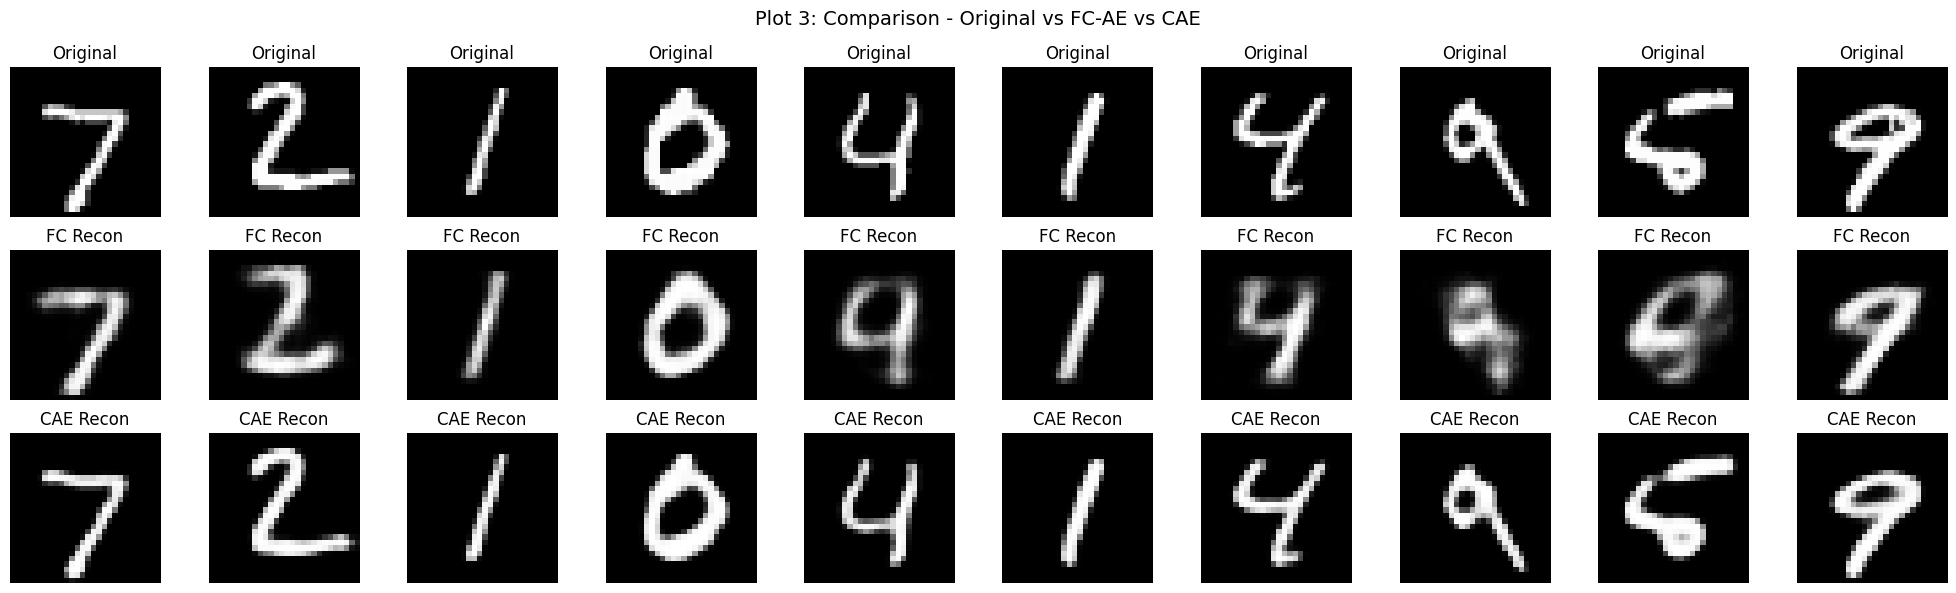


--- Model Comparison Table ---
           Model      MSE      MAE     SSIM  Parameters
  FC Autoencoder 0.023439 0.061066 0.721732      211040
Conv Autoencoder 0.002389 0.014447 0.975975       74497


In [ ]:
# 1. Build Convolutional Autoencoder
cae_input = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(cae_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded_cae = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_cae)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
cae_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

cae_autoencoder = models.Model(cae_input, cae_output, name="Conv_Autoencoder")
cae_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 2. Train CAE
start_time = time.time()
history_cae = cae_autoencoder.fit(
    x_train_conv, x_train_conv,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_conv, x_test_conv),
    verbose=1
)
cae_train_time = time.time() - start_time

# 3. Evaluate Metrics
cae_preds = cae_autoencoder.predict(x_test_conv)
cae_mse, cae_mae, cae_ssim = compute_metrics(x_test_conv, cae_preds)
cae_params = cae_autoencoder.count_params()

consolidated_results.append({
    'Model': 'Conv Autoencoder',
    'MSE': cae_mse, 'MAE': cae_mae, 'SSIM': cae_ssim,
    'Parameters': cae_params, 'Time (s)': cae_train_time
})

# Plot 3: Original vs FC-AE Reconstruction vs CAE Reconstruction
plt.figure(figsize=(20, 6))
for i in range(10):
    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test_conv[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # FC Recon
    plt.subplot(3, 10, i + 11)
    plt.imshow(fc_preds_flat[i].reshape(28, 28), cmap='gray')
    plt.title("FC Recon")
    plt.axis("off")

    # CAE Recon
    plt.subplot(3, 10, i + 21)
    plt.imshow(cae_preds[i].squeeze(), cmap='gray')
    plt.title("CAE Recon")
    plt.axis("off")
plt.suptitle("Plot 3: Comparison - Original vs FC-AE vs CAE", fontsize=14)
plt.tight_layout()
plt.show()

# Table Comparison between FC-AE and CAE
df_comp = pd.DataFrame([consolidated_results[0], consolidated_results[1]])
print("\n--- Model Comparison Table ---")
print(df_comp[['Model', 'MSE', 'MAE', 'SSIM', 'Parameters']].to_string(index=False))

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2306 - val_loss: 0.1159
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1021 - val_loss: 0.0921
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0906 - val_loss: 0.0870
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0862 - val_loss: 0.0841
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0836 - val_loss: 0.0819
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0819 - val_loss: 0.0799
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0805 - val_loss: 0.0787
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0795 - val_loss: 0.0781
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0787 - val_loss: 0.0771
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0781 - val_loss: 0.0766
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0776 - val_loss: 0.0759
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0771 - val_

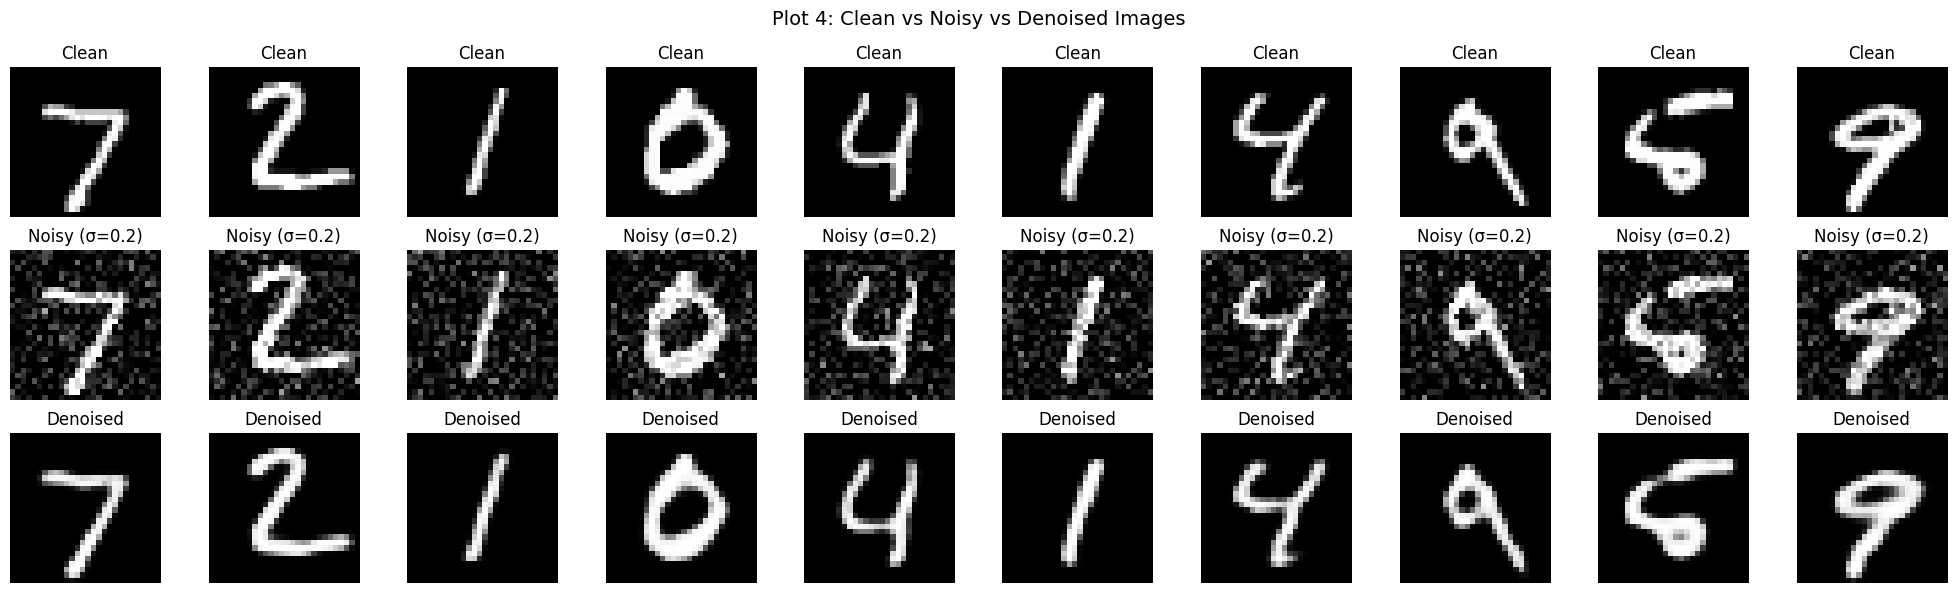

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Noise Level vs Reconstruction Quality Table ---
 Noise Level      MSE      MAE     SSIM
         0.1 0.003437 0.017135 0.960659
         0.2 0.004449 0.020646 0.946232
         0.3 0.006736 0.028012 0.881387


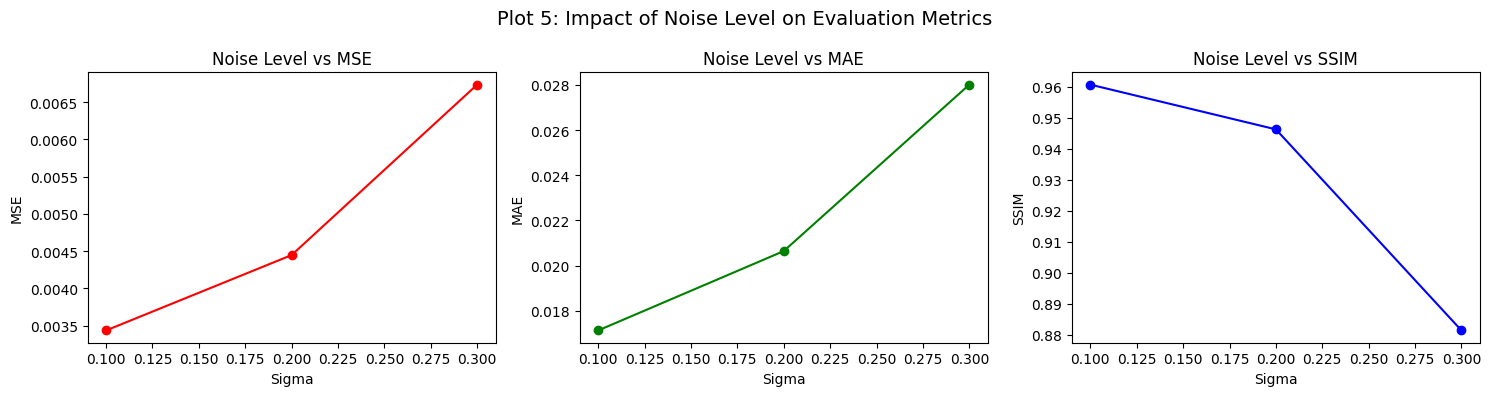

In [ ]:
# Helper Functions for Noise Generation
def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(loc=0.0, scale=sigma, size=images.shape)
    return np.clip(noisy, 0.0, 1.0)

def add_salt_and_pepper_noise(images, amount):
    noisy = np.copy(images)
    # Salt noise
    num_salt = np.ceil(amount * images.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in images.shape]
    noisy[tuple(coords)] = 1
    # Pepper noise
    num_pepper = np.ceil(amount * images.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in images.shape]
    noisy[tuple(coords)] = 0
    return noisy

# Generate Gaussian Noisy Sets
x_train_noisy_02 = add_gaussian_noise(x_train_conv, sigma=0.2)
x_test_noisy_02 = add_gaussian_noise(x_test_conv, sigma=0.2)

# Build & Train Denoising Autoencoder (DAE) on sigma = 0.2
dae_model = models.clone_model(cae_autoencoder)
dae_model.compile(optimizer='adam', loss='binary_crossentropy')

start_time = time.time()
dae_model.fit(
    x_train_noisy_02, x_train_conv, # Target remains clean
    epochs=20,
    batch_size=128,
    validation_data=(x_test_noisy_02, x_test_conv),
    verbose=1
)
dae_train_time = time.time() - start_time

dae_preds = dae_model.predict(x_test_noisy_02)
dae_mse, dae_mae, dae_ssim = compute_metrics(x_test_conv, dae_preds)

consolidated_results.append({
    'Model': 'Denoising CAE (σ=0.2)',
    'MSE': dae_mse, 'MAE': dae_mae, 'SSIM': dae_ssim,
    'Parameters': dae_model.count_params(), 'Time (s)': dae_train_time
})

# Plot 4: Clean vs Noisy vs Denoised
plt.figure(figsize=(20, 6))
for i in range(10):
    # Clean
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test_conv[i].squeeze(), cmap='gray')
    plt.title("Clean")
    plt.axis("off")

    # Noisy
    plt.subplot(3, 10, i + 11)
    plt.imshow(x_test_noisy_02[i].squeeze(), cmap='gray')
    plt.title("Noisy (σ=0.2)")
    plt.axis("off")

    # Denoised
    plt.subplot(3, 10, i + 21)
    plt.imshow(dae_preds[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")
plt.suptitle("Plot 4: Clean vs Noisy vs Denoised Images", fontsize=14)
plt.tight_layout()
plt.show()

# Plot 5: Noise Level vs Reconstruction Quality Evaluation
noise_levels = [0.1, 0.2, 0.3]
noise_metrics = []

for sig in noise_levels:
    test_noisy = add_gaussian_noise(x_test_conv, sigma=sig)
    preds = dae_model.predict(test_noisy)
    m_mse, m_mae, m_ssim = compute_metrics(x_test_conv, preds)
    noise_metrics.append({'Noise Level': sig, 'MSE': m_mse, 'MAE': m_mae, 'SSIM': m_ssim})

df_noise = pd.DataFrame(noise_metrics)
print("\n--- Noise Level vs Reconstruction Quality Table ---")
print(df_noise.to_string(index=False))

# Plotting metrics separately as instructed
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(noise_levels, df_noise['MSE'], marker='o', color='r')
ax[0].set_title("Noise Level vs MSE"); ax[0].set_xlabel("Sigma"); ax[0].set_ylabel("MSE")

ax[1].plot(noise_levels, df_noise['MAE'], marker='o', color='g')
ax[1].set_title("Noise Level vs MAE"); ax[1].set_xlabel("Sigma"); ax[1].set_ylabel("MAE")

ax[2].plot(noise_levels, df_noise['SSIM'], marker='o', color='b')
ax[2].set_title("Noise Level vs SSIM"); ax[2].set_xlabel("Sigma"); ax[2].set_ylabel("SSIM")

plt.suptitle("Plot 5: Impact of Noise Level on Evaluation Metrics", fontsize=14)
plt.tight_layout()
plt.show()

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - kl_loss: 0.9629 - loss: 311.1938 - reconstruction_loss: 310.2308 - val_kl_loss: 0.1523 - val_loss: 206.1286 - val_reconstruction_loss: 205.9763
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 0.8977 - loss: 208.4754 - reconstruction_loss: 207.5777 - val_kl_loss: 1.7905 - val_loss: 195.3790 - val_reconstruction_loss: 193.5884
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 2.2115 - loss: 197.5731 - reconstruction_loss: 195.3616 - val_kl_loss: 2.1811 - val_loss: 188.0203 - val_reconstruction_loss: 185.8392
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 2.3912 - loss: 192.6855 - reconstruction_loss: 190.2943 - val_kl_loss: 2.3091 - val_loss: 185.1412 - val_reconstruction_loss: 182.8322
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 2.3339 - loss: 189.3348 - reconstruction_loss: 187.0008 - val_kl_loss: 2.3945 - val_loss: 183.4556 - val_reconstruction_loss: 181.0612
Epoch 6/20
79/79 ━

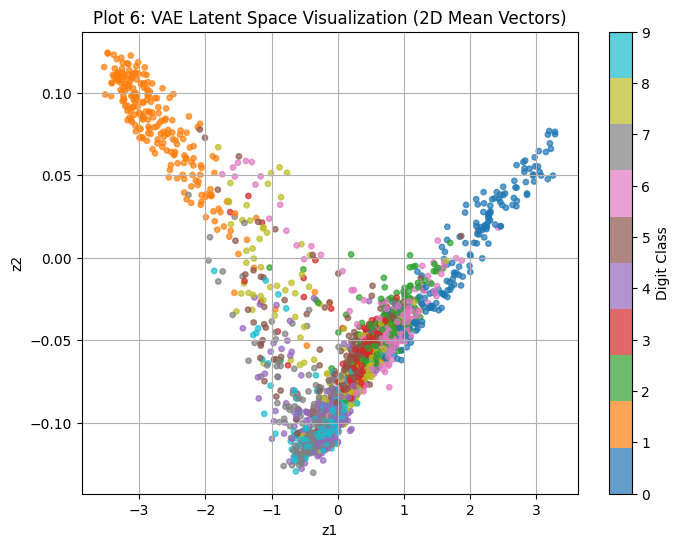

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step


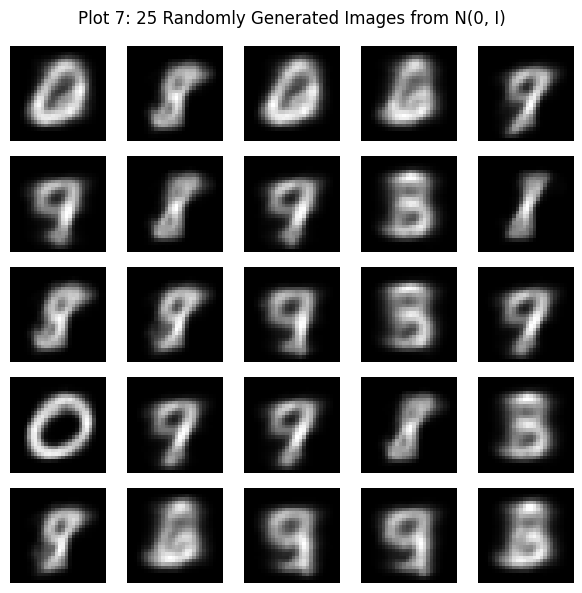

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


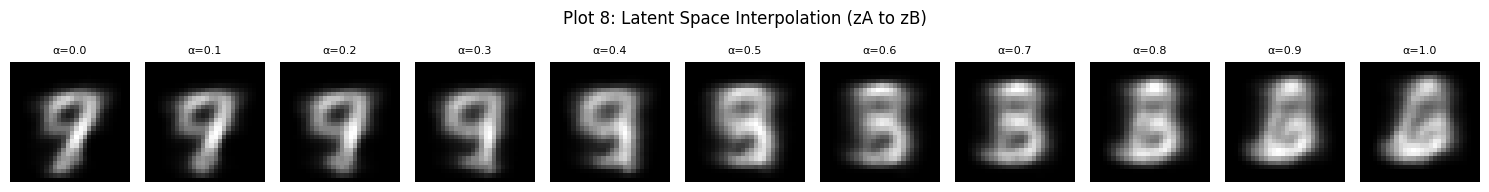

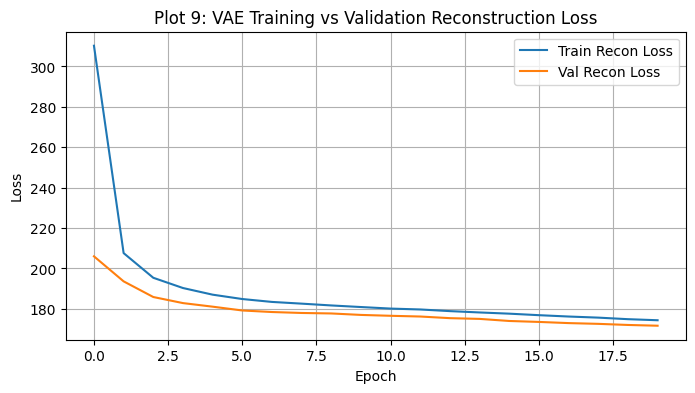

In [ ]:
# 1. Reparameterization Sampling Layer
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 2. VAE Architecture (Latent Dim = 2)
latent_dim = 2

# Encoder
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="VAE_Encoder")

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
vae_decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = models.Model(latent_inputs, vae_decoder_outputs, name="VAE_Decoder")

# 3. Custom VAE Model
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction Loss (Sum over spatial dimensions)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            # KL Divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        recon_loss = tf.reduce_mean(
            tf.reduce_sum(losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Train VAE
vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

start_time = time.time()
history_vae = vae.fit(x_train_conv, epochs=20, batch_size=128, validation_data=(x_test_conv, None), verbose=1)
vae_train_time = time.time() - start_time

# VAE Evaluation
z_mean_test, _, z_test = vae_encoder.predict(x_test_conv)
vae_preds = vae_decoder.predict(z_test)
vae_mse, vae_mae, vae_ssim = compute_metrics(x_test_conv, vae_preds)

# FIX: Sum parameter counts of encoder and decoder explicitly to avoid unbuilt model error
vae_params = vae_encoder.count_params() + vae_decoder.count_params()

consolidated_results.append({
    'Model': 'VAE (z_dim=2)',
    'MSE': vae_mse, 'MAE': vae_mae, 'SSIM': vae_ssim,
    'Parameters': vae_params, 'Time (s)': vae_train_time
})

# Plot 6: VAE Latent Space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap='tab10', alpha=0.7, s=15)
plt.colorbar(scatter, label='Digit Class')
plt.xlabel("z1"); plt.ylabel("z2")
plt.title("Plot 6: VAE Latent Space Visualization (2D Mean Vectors)")
plt.grid(True)
plt.show()

# Plot 7: Randomly Generated Images from Latent Prior N(0, I)
plt.figure(figsize=(6, 6))
random_latents = np.random.normal(size=(25, 2))
generated_images = vae_decoder.predict(random_latents)

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Plot 7: 25 Randomly Generated Images from N(0, I)")
plt.tight_layout()
plt.show()

# Plot 8: Latent Space Interpolation
zA, zB = z_mean_test[0], z_mean_test[1] # Choose two sample embeddings
alphas = np.linspace(0, 1, 11)
interpolated_vectors = np.array([(1 - a) * zA + a * zB for a in alphas])
decoded_interpolations = vae_decoder.predict(interpolated_vectors)

plt.figure(figsize=(15, 2))
for i in range(11):
    plt.subplot(1, 11, i + 1)
    plt.imshow(decoded_interpolations[i].squeeze(), cmap='gray')
    plt.title(f"α={alphas[i]:.1f}", fontsize=8)
    plt.axis('off')
plt.suptitle("Plot 8: Latent Space Interpolation (zA to zB)", fontsize=12)
plt.tight_layout()
plt.show()

# Plot 9: Training and Validation Reconstruction Loss for VAE
plt.figure(figsize=(8, 4))
plt.plot(history_vae.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history_vae.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Plot 9: VAE Training vs Validation Reconstruction Loss')
plt.legend(); plt.grid(True)
plt.show()

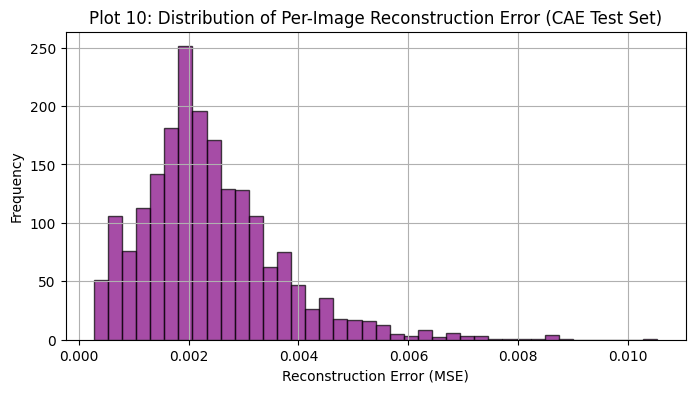

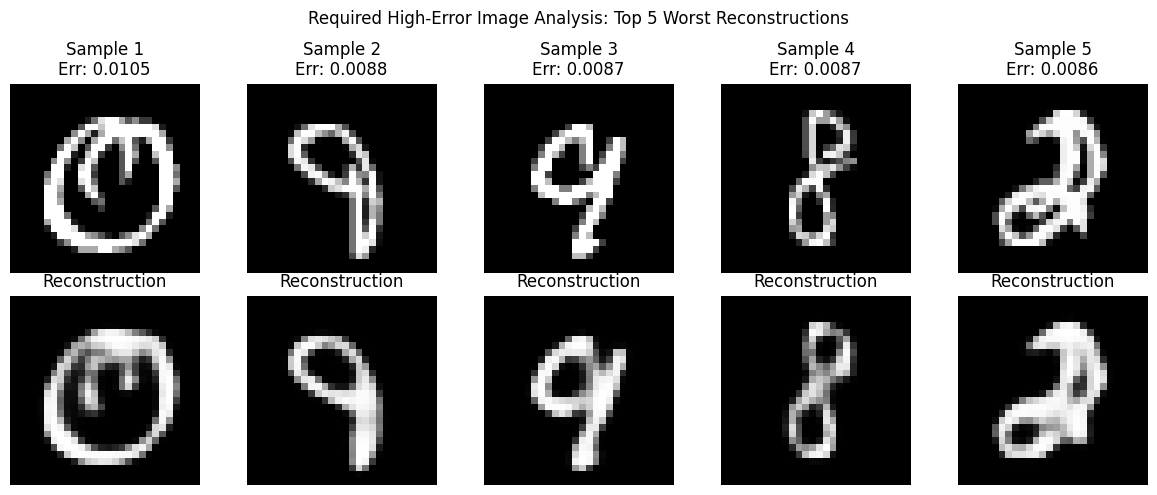


--- Additional Latent Dimension Study ---
 Latent Dimension      MSE     SSIM  Parameters
                2 0.052329 0.349026      202258
                8 0.032333 0.612194      203800
               16 0.022075 0.726912      205856
               32 0.017568 0.775728      209968


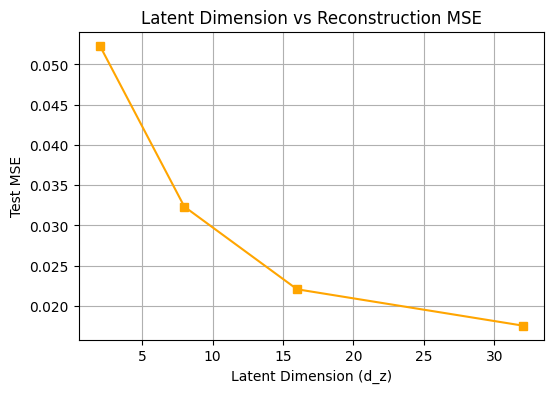

In [ ]:
# Per-image Reconstruction Error (using CAE)
per_image_mse = np.mean((x_test_conv - cae_preds) ** 2, axis=(1, 2, 3))

# Plot 10: Histogram of Reconstruction Errors
plt.figure(figsize=(8, 4))
plt.hist(per_image_mse, bins=40, color='purple', alpha=0.7, edgecolor='black')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.title('Plot 10: Distribution of Per-Image Reconstruction Error (CAE Test Set)')
plt.grid(True)
plt.show()

# High-Error Image Analysis (Top 5 worst reconstructed samples)
top5_indices = np.argsort(per_image_mse)[-5:][::-1]

plt.figure(figsize=(12, 5))
for i, idx in enumerate(top5_indices):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_conv[idx].squeeze(), cmap='gray')
    plt.title(f"Sample {i+1}\nErr: {per_image_mse[idx]:.4f}")
    plt.axis('off')

    # Reconstruction
    plt.subplot(2, 5, i + 6)
    plt.imshow(cae_preds[idx].squeeze(), cmap='gray')
    plt.title("Reconstruction")
    plt.axis('off')
plt.suptitle("Required High-Error Image Analysis: Top 5 Worst Reconstructions", fontsize=12)
plt.tight_layout()
plt.show()

# Additional Latent Dimension Study for Basic Autoencoder (Fixed for Keras 3 Functional API)
latent_dims = [2, 8, 16, 32]
dim_study_results = []

for d in latent_dims:
    # Encoder
    enc_in = layers.Input(shape=(784,))
    x = layers.Dense(128, activation='relu')(enc_in)
    enc_out = layers.Dense(d, activation='relu')(x)
    enc = models.Model(enc_in, enc_out)

    # Decoder
    dec_in = layers.Input(shape=(d,))
    y = layers.Dense(128, activation='relu')(dec_in)
    dec_out = layers.Dense(784, activation='sigmoid')(y)
    dec = models.Model(dec_in, dec_out)

    # Autoencoder
    ae = models.Model(enc_in, dec(enc(enc_in)))
    ae.compile(optimizer='adam', loss='binary_crossentropy')
    ae.fit(x_train_flat, x_train_flat, epochs=10, batch_size=128, verbose=0)

    preds = ae.predict(x_test_flat, verbose=0)
    m_mse, _, m_ssim = compute_metrics(x_test_flat, preds)
    dim_study_results.append({'Latent Dimension': d, 'MSE': m_mse, 'SSIM': m_ssim, 'Parameters': ae.count_params()})

df_dim = pd.DataFrame(dim_study_results)
print("\n--- Additional Latent Dimension Study ---")
print(df_dim.to_string(index=False))

# Plot Latent Dimension vs MSE
plt.figure(figsize=(6, 4))
plt.plot(df_dim['Latent Dimension'], df_dim['MSE'], marker='s', color='orange')
plt.xlabel('Latent Dimension (d_z)')
plt.ylabel('Test MSE')
plt.title('Latent Dimension vs Reconstruction MSE')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
tf.random.set_seed(42)

# Load MNIST Dataset & Subset (10k Train / 2k Test)
(x_train_full, _), (x_test_full, _) = keras.datasets.mnist.load_data()
x_train = x_train_full[:10000].astype("float32") / 255.0
x_test = x_test_full[:2000].astype("float32") / 255.0

x_train_conv = np.expand_dims(x_train, axis=-1)
x_test_conv = np.expand_dims(x_test, axis=-1)

# Helper Function: Metric Evaluation
def evaluate_reconstruction(orig_images, recon_images):
    orig_2d, recon_2d = orig_images.reshape(-1, 28, 28), recon_images.reshape(-1, 28, 28)
    mse = np.mean((orig_2d - recon_2d) ** 2)
    mae = np.mean(np.abs(orig_2d - recon_2d))
    mean_ssim = np.mean([ssim(orig_2d[i], recon_2d[i], data_range=1.0) for i in range(len(orig_2d))])
    return mse, mae, mean_ssim

# Fixed Noise Generators
def add_gaussian_noise(images, sigma):
    return np.clip(images + np.random.normal(0.0, sigma, images.shape), 0.0, 1.0)

def add_sp_noise(images, p=0.10):
    noisy = np.copy(images)
    num_pixels = images.shape[1] * images.shape[2]
    num_corrupt = int(p * num_pixels / 2)

    for i in range(len(images)):
        # Salt (1.0)
        r_salt = np.random.randint(0, images.shape[1], num_corrupt)
        c_salt = np.random.randint(0, images.shape[2], num_corrupt)
        noisy[i, r_salt, c_salt, 0] = 1.0

        # Pepper (0.0)
        r_pep = np.random.randint(0, images.shape[1], num_corrupt)
        c_pep = np.random.randint(0, images.shape[2], num_corrupt)
        noisy[i, r_pep, c_pep, 0] = 0.0

    return noisy

# --- Exercise 1: CAE Latent Dimension Comparison (4, 8, 16, 32) ---
print("=== Exercise 1: CAE Latent Dimension Comparison ===")
for d in [4, 8, 16, 32]:
    inp = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(d)(x)

    x = layers.Dense(7 * 7 * 64, activation='relu')(latent)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    ae = Model(inp, out)
    ae.compile(optimizer='adam', loss='binary_crossentropy')
    ae.fit(x_train_conv, x_train_conv, epochs=10, batch_size=128, verbose=0)

    preds = ae.predict(x_test_conv, verbose=0)
    mse, mae, mean_ssim = evaluate_reconstruction(x_test_conv, preds)
    print(f"Latent Dim: {d:2d} | MSE: {mse:.5f} | MAE: {mae:.5f} | SSIM: {mean_ssim:.5f}")

# --- Denoising CAE Architecture Builder ---
def build_denoising_cae():
    inp = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    enc = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(enc)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

# --- Exercise 2: Gaussian vs. Salt & Pepper Noise Comparison ---
x_tr_g, x_te_g = add_gaussian_noise(x_train_conv, 0.2), add_gaussian_noise(x_test_conv, 0.2)
x_tr_sp, x_te_sp = add_sp_noise(x_train_conv, 0.10), add_sp_noise(x_test_conv, 0.10)

dae_g = build_denoising_cae()
dae_g.fit(x_tr_g, x_train_conv, epochs=10, batch_size=128, verbose=0)
pred_g = dae_g.predict(x_te_g, verbose=0)
mse_g, mae_g, ssim_g = evaluate_reconstruction(x_test_conv, pred_g)

dae_sp = build_denoising_cae()
dae_sp.fit(x_tr_sp, x_train_conv, epochs=10, batch_size=128, verbose=0)
pred_sp = dae_sp.predict(x_te_sp, verbose=0)
mse_sp, mae_sp, ssim_sp = evaluate_reconstruction(x_test_conv, pred_sp)

print("\n=== Exercise 2: Gaussian vs. Salt & Pepper Denoising ===")
print(f"Gaussian (sigma=0.2) | MSE: {mse_g:.5f} | MAE: {mae_g:.5f} | SSIM: {ssim_g:.5f}")
print(f"Salt&Pepper (p=0.10) | MSE: {mse_sp:.5f} | MAE: {mae_sp:.5f} | SSIM: {ssim_sp:.5f}")

# --- Exercise 3: Noise Level Comparison (SSIM at Low vs. High Noise) ---
x_tr_n1, x_te_n1 = add_gaussian_noise(x_train_conv, 0.1), add_gaussian_noise(x_test_conv, 0.1)
x_tr_n3, x_te_n3 = add_gaussian_noise(x_train_conv, 0.3), add_gaussian_noise(x_test_conv, 0.3)

dae_low = build_denoising_cae()
dae_low.fit(x_tr_n1, x_train_conv, epochs=10, batch_size=128, verbose=0)
_, _, ssim_low = evaluate_reconstruction(x_test_conv, dae_low.predict(x_te_n1, verbose=0))

dae_high = build_denoising_cae()
dae_high.fit(x_tr_n3, x_train_conv, epochs=10, batch_size=128, verbose=0)
_, _, ssim_high = evaluate_reconstruction(x_test_conv, dae_high.predict(x_te_n3, verbose=0))

print("\n=== Exercise 3: SSIM Across Noise Levels ===")
print(f"Low Noise  (sigma=0.1) -> Mean SSIM: {ssim_low:.5f}")
print(f"High Noise (sigma=0.3) -> Mean SSIM: {ssim_high:.5f}")

# --- Exercise 4: Transposed Convolutional Autoencoder ---
inp_t = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp_t)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
enc_t = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(enc_t)
x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
out_t = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

trans_cae = Model(inp_t, out_t)
trans_cae.compile(optimizer='adam', loss='binary_crossentropy')
trans_cae.fit(x_train_conv, x_train_conv, epochs=10, batch_size=128, verbose=0)

mse_t, mae_t, ssim_t = evaluate_reconstruction(x_test_conv, trans_cae.predict(x_test_conv, verbose=0))
print("\n=== Exercise 4: Transposed Convolutional Autoencoder ===")
print(f"Transposed CAE | MSE: {mse_t:.5f} | MAE: {mae_t:.5f} | SSIM: {ssim_t:.5f}")

=== Exercise 1: CAE Latent Dimension Comparison ===
Latent Dim:  4 | MSE: 0.03543 | MAE: 0.08410 | SSIM: 0.62334
Latent Dim:  8 | MSE: 0.02113 | MAE: 0.05459 | SSIM: 0.76908
Latent Dim: 16 | MSE: 0.01214 | MAE: 0.03706 | SSIM: 0.86951
Latent Dim: 32 | MSE: 0.00753 | MAE: 0.02743 | SSIM: 0.91859

=== Exercise 2: Gaussian vs. Salt & Pepper Denoising ===
Gaussian (sigma=0.2) | MSE: 0.00544 | MAE: 0.02332 | SSIM: 0.93635
Salt&Pepper (p=0.10) | MSE: 0.00580 | MAE: 0.02352 | SSIM: 0.93500

=== Exercise 3: SSIM Across Noise Levels ===
Low Noise  (sigma=0.1) -> Mean SSIM: 0.95328
High Noise (sigma=0.3) -> Mean SSIM: 0.89091

=== Exercise 4: Transposed Convolutional Autoencoder ===
Transposed CAE | MSE: 0.00257 | MAE: 0.01487 | SSIM: 0.97342


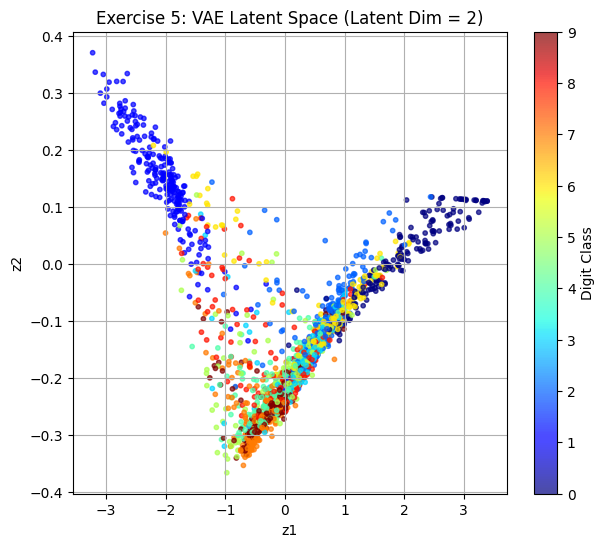


=== Exercise 6: Beta-VAE KL-Loss Weight Sweep ===
KL Weight (beta): 0.1 | Test MSE: 0.04825 | Test SSIM: 0.41761
KL Weight (beta): 1.0 | Test MSE: 0.04762 | Test SSIM: 0.43240
KL Weight (beta): 5.0 | Test MSE: 0.05713 | Test SSIM: 0.29243


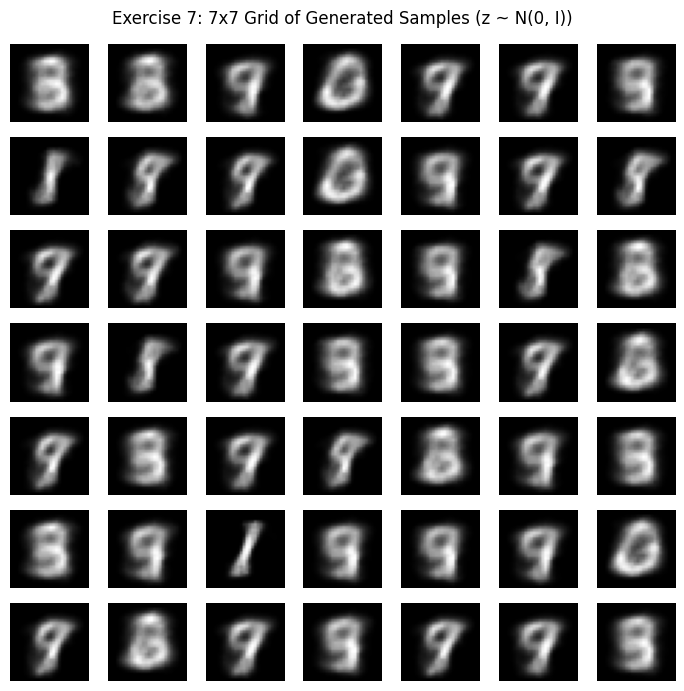

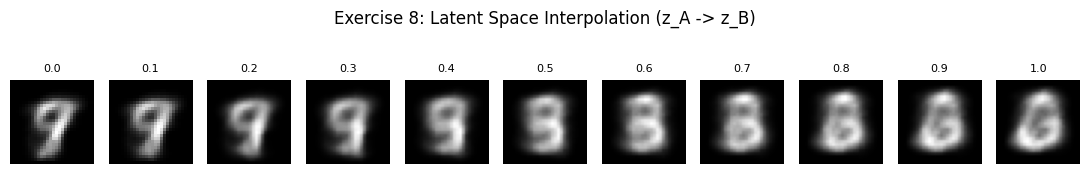

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
tf.random.set_seed(42)

# Load Dataset
(x_train_full, _), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()
x_train = x_train_full[:10000].astype("float32") / 255.0
x_test = x_test_full[:2000].astype("float32") / 255.0
y_test = y_test_full[:2000]

x_train_conv = np.expand_dims(x_train, axis=-1)
x_test_conv = np.expand_dims(x_test, axis=-1)

# Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

# VAE Model Class
class VAE(Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

    def train_step(self, data):
        if isinstance(data, tuple): data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            recon = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(data, recon), axis=(1, 2)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = recon_loss + (self.beta * kl_loss)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

def build_vae(latent_dim=2, beta=1.0):
    enc_in = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(enc_in)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)
    z_m = layers.Dense(latent_dim)(x)
    z_lv = layers.Dense(latent_dim)(x)
    z = Sampling()([z_m, z_lv])
    encoder = Model(enc_in, [z_m, z_lv, z])

    dec_in = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(dec_in)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    dec_out = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
    decoder = Model(dec_in, dec_out)

    vae = VAE(encoder, decoder, beta=beta)
    vae.compile(optimizer="adam")
    return vae, encoder, decoder

# --- Exercise 5: VAE Latent Dims 2 and 8 & Scatter Plot ---
vae_dim2, enc_dim2, dec_dim2 = build_vae(latent_dim=2)
vae_dim2.fit(x_train_conv, epochs=15, batch_size=128, verbose=0)

vae_dim8, enc_dim8, dec_dim8 = build_vae(latent_dim=8)
vae_dim8.fit(x_train_conv, epochs=15, batch_size=128, verbose=0)

# Scatter plot for latent dim 2
z_mean_2, _, _ = enc_dim2.predict(x_test_conv, verbose=0)
plt.figure(figsize=(7, 6))
plt.scatter(z_mean_2[:, 0], z_mean_2[:, 1], c=y_test, cmap="jet", alpha=0.7, s=10)
plt.colorbar(label="Digit Class"); plt.xlabel("z1"); plt.ylabel("z2")
plt.title("Exercise 5: VAE Latent Space (Latent Dim = 2)")
plt.grid(True); plt.show()

# --- Exercise 6: Effect of Increasing KL Loss Contribution (Beta-VAE) ---
print("\n=== Exercise 6: Beta-VAE KL-Loss Weight Sweep ===")
for beta in [0.1, 1.0, 5.0]:
    vae_beta, enc_beta, dec_beta = build_vae(latent_dim=2, beta=beta)
    vae_beta.fit(x_train_conv, epochs=15, batch_size=128, verbose=0)

    z_m, _, _ = enc_beta.predict(x_test_conv, verbose=0)
    recons = dec_beta.predict(z_m, verbose=0)
    mse = np.mean((x_test_conv.reshape(-1, 28, 28) - recons.reshape(-1, 28, 28)) ** 2)
    mean_ssim = np.mean([ssim(x_test[i], recons[i].reshape(28, 28), data_range=1.0) for i in range(len(x_test))])
    print(f"KL Weight (beta): {beta:3.1f} | Test MSE: {mse:.5f} | Test SSIM: {mean_ssim:.5f}")

# --- Exercise 7: Larger Grid of VAE Samples (7x7 Grid) ---
sampled_z = np.random.normal(size=(49, 2))
gen_imgs = dec_dim2.predict(sampled_z, verbose=0)

plt.figure(figsize=(7, 7))
for i in range(49):
    plt.subplot(7, 7, i + 1)
    plt.imshow(gen_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("Exercise 7: 7x7 Grid of Generated Samples (z ~ N(0, I))")
plt.tight_layout(); plt.show()

# --- Exercise 8: Latent Space Interpolation ---
z_start = z_mean_2[0]
z_end = z_mean_2[1]
alphas = np.linspace(0, 1, 11)
interp_z = np.array([(1 - a) * z_start + a * z_end for a in alphas])
interp_imgs = dec_dim2.predict(interp_z, verbose=0)

plt.figure(figsize=(11, 2))
for i, alpha in enumerate(alphas):
    plt.subplot(1, 11, i + 1)
    plt.imshow(interp_imgs[i].reshape(28, 28), cmap="gray")
    plt.title(f"{alpha:.1f}", fontsize=8)
    plt.axis("off")
plt.suptitle("Exercise 8: Latent Space Interpolation (z_A -> z_B)")
plt.tight_layout(); plt.show()